<a href="https://colab.research.google.com/github/raja-ankit06/SIP-Data-Science-Internship/blob/main/Crop_Disease_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator


In [ ]:
# 1. Create directory
!mkdir -p ~/.kaggle

# 2. Upload your kaggle.json
from google.colab import files
files.upload()  # Upload kaggle.json here

# 3. Move it to correct location
!mv kaggle.json ~/.kaggle/

# 4. Set permissions
!chmod 600 ~/.kaggle/kaggle.json

# 5. Install kaggle package
!pip install -q kaggle

# 6. Download dataset
!kaggle datasets download -d emmarex/plantdisease

Saving kaggle (4).json to kaggle (4).json
mv: cannot stat 'kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/emmarex/plantdisease
License(s): unknown


In [ ]:
os.chmod('/root/.kaggle/kaggle.json', 600)


In [ ]:
!ls -l /root/.kaggle/kaggle.json


---x-wx--T 1 root root 66 May 10 03:06 /root/.kaggle/kaggle.json


In [ ]:
import os

# List files in the current directory
os.listdir('/content')


['.config', 'plantdisease.zip', 'kaggle (4).json', 'sample_data']

In [ ]:
!pip install kaggle


In [ ]:
import zipfile
import os

# Path to the downloaded zip file
zip_path = '/content/plantdisease.zip'


# Check if file exists before extracting
if os.path.exists(zip_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall('/content/data')
    print("✅ Dataset extracted successfully to /content/data!")
else:
    print("❌ Zip file not found. Please check the file path.")


✅ Dataset extracted successfully to /content/data!


In [ ]:
import os
base_dir = '/content/data'
print(os.listdir(base_dir))


['plantvillage', 'PlantVillage']


In [ ]:
# Check contents of both folders
folder1 = '/content/data/plantvillage'
folder2 = '/content/data/PlantVillage'

print("Contents of plantvillage folder:")
print(os.listdir(folder1))

print("\nContents of PlantVillage folder:")
print(os.listdir(folder2))


Contents of plantvillage folder:
['PlantVillage']

Contents of PlantVillage folder:
['Tomato_Early_blight', 'Pepper__bell___healthy', 'Tomato_Late_blight', 'Tomato_Septoria_leaf_spot', 'Potato___healthy', 'Tomato__Target_Spot', 'Potato___Late_blight', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato_Leaf_Mold', 'Potato___Early_blight', 'Tomato_healthy', 'Tomato__Tomato_mosaic_virus', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato_Bacterial_spot', 'Pepper__bell___Bacterial_spot']


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Set up the ImageDataGenerator with validation split
train_datagen = ImageDataGenerator(
    rescale=1./255,  # Rescale images by 1/255 (to normalize pixel values)
    shear_range=0.2,  # Random shear for augmentation
    zoom_range=0.2,  # Random zoom for augmentation
    horizontal_flip=True,  # Randomly flip images horizontally
    validation_split=0.2  # 20% of the data will be used for validation
)

# Load training data
train_dir = '/content/data/PlantVillage'  # Path to your dataset

train_generator = train_datagen.flow_from_directory(
    train_dir,  # Path to training data folder
    target_size=(150, 150),  # Resize images to 150x150
    batch_size=32,  # Batch size for training
    class_mode='categorical',  # Multi-class classification
    subset='training'  # Specify that this is the training set
)

# Load validation data
validation_generator = train_datagen.flow_from_directory(
    train_dir,  # Same folder, now with validation split
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    subset='validation'  # Specify that this is the validation set
)


Found 16516 images belonging to 15 classes.
Found 4122 images belonging to 15 classes.


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Build the CNN model
model = Sequential()

# Convolutional layer with 32 filters, a 3x3 kernel, and ReLU activation
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Second convolutional layer with 64 filters
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Third convolutional layer with 128 filters
model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Flatten the 3D feature maps into 1D vector
model.add(Flatten())

# Fully connected layer with 128 neurons
model.add(Dense(128, activation='relu'))

# Dropout layer to prevent overfitting
model.add(Dropout(0.5))

# Output layer with softmax activation for multi-class classification
model.add(Dense(15, activation='softmax'))  # 15 classes for 15 plant diseases

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Summarize the model architecture
model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 15)             │         1,935 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,830,287 (18.43 MB)

 Trainable params: 4,830,287 (18.43 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
  train_generator,
  epochs=20,
  validation_data=validation_generator
)


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/12
517/517 ━━━━━━━━━━━━━━━━━━━━ 956s 2s/step - accuracy: 0.2791 - loss: 2.2291 - val_accuracy: 0.6405 - val_loss: 1.1178
Epoch 2/12
517/517 ━━━━━━━━━━━━━━━━━━━━ 931s 2s/step - accuracy: 0.5541 - loss: 1.3690 - val_accuracy: 0.7268 - val_loss: 0.8603
Epoch 3/12
517/517 ━━━━━━━━━━━━━━━━━━━━ 912s 2s/step - accuracy: 0.6313 - loss: 1.0716 - val_accuracy: 0.7914 - val_loss: 0.6430
Epoch 4/12
517/517 ━━━━━━━━━━━━━━━━━━━━ 920s 2s/step - accuracy: 0.6839 - loss: 0.9471 - val_accuracy: 0.8188 - val_loss: 0.5701
Epoch 5/12
517/517 ━━━━━━━━━━━━━━━━━━━━ 902s 2s/step - accuracy: 0.7119 - loss: 0.8429 - val_accuracy: 0.8523 - val_loss: 0.4629
Epoch 6/12
517/517 ━━━━━━━━━━━━━━━━━━━━ 898s 2s/step - accuracy: 0.7413 - loss: 0.7638 - val_accuracy: 0.8370 - val_loss: 0.5337
Epoch 7/12
517/517 ━━━━━━━━━━━━━━━━━━━━ 906s 2s/step - accuracy: 0.7550 - loss: 0.6903 - val_accuracy: 0.8712 - val_loss: 0.3930
Epoch 8/12
517/517 ━━━━━━━━━━━━━━━━━━━━ 896s 2s/step - accuracy: 0.7743 - loss: 0.6692 - val_accu

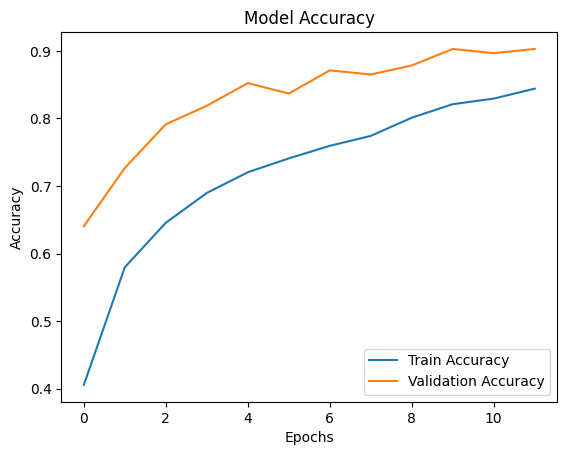

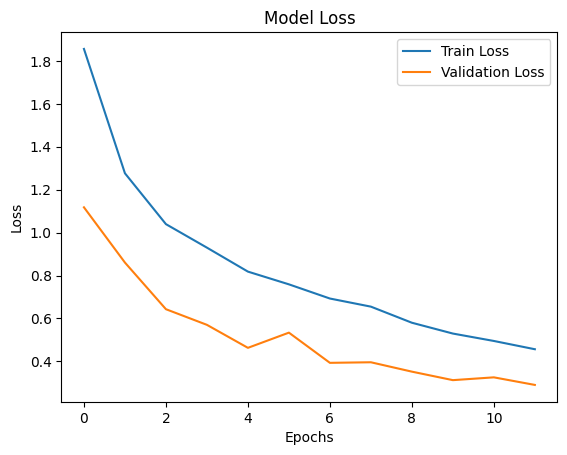

In [ ]:
import matplotlib.pyplot as plt

# Accuracy Plot
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Loss Plot
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


In [ ]:
model.save('plant_disease_model.h5')


In [ ]:
from google.colab import files
from tensorflow.keras.preprocessing import image
import numpy as np

# Step 1: Upload image
uploaded = files.upload()

# Step 2: Get uploaded file name
img_path = next(iter(uploaded))

# Step 3: Load and preprocess the image
img = image.load_img(img_path, target_size=(150, 150))  # resize as per model input
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0) / 255.0  # normalize & add batch dim

# Step 4: Predict
prediction = model.predict(img_array)
predicted_class = np.argmax(prediction[0])

# Step 5: Get label names from train_generator
class_labels = list(train_generator.class_indices.keys())

# Step 6: Output result
print(f"Predicted Class: {class_labels[predicted_class]}")


Saving potato_leaf.jpg to potato_leaf.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 228ms/step
Predicted Class: Potato___Early_blight


Saving potato_leaf.jpg to potato_leaf (1).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
Predicted Class: Potato___Early_blight


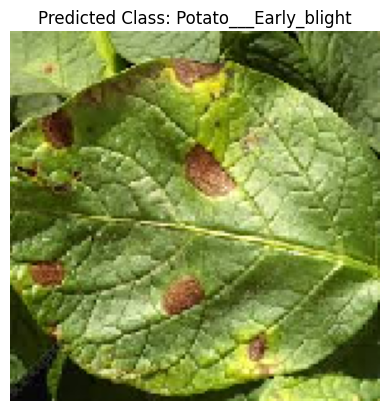

In [ ]:
import matplotlib.pyplot as plt
from google.colab import files
from tensorflow.keras.preprocessing import image
import numpy as np

# Step 1: Upload image
uploaded = files.upload()

# Step 2: Get uploaded file name
img_path = next(iter(uploaded))

# Step 3: Load and preprocess the image
img = image.load_img(img_path, target_size=(150, 150))  # resize as per model input
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0) / 255.0  # normalize & add batch dim

# Step 4: Predict
prediction = model.predict(img_array)
predicted_class = np.argmax(prediction[0])

# Step 5: Get label names from train_generator
class_labels = list(train_generator.class_indices.keys())

# Step 6: Output result
print(f"Predicted Class: {class_labels[predicted_class]}")

# Step 7: Show the image with the prediction
plt.imshow(img)
plt.title(f"Predicted Class: {class_labels[predicted_class]}")
plt.axis('off')  # Hide axes for better viewing
plt.show()


Saving potato_leaf.jpg to potato_leaf (2).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
Predicted Class: Potato___Early_blight


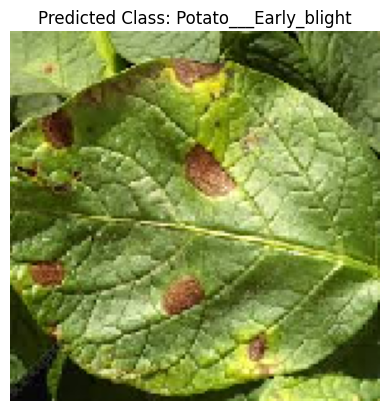

In [ ]:
import matplotlib.pyplot as plt
from google.colab import files
from tensorflow.keras.preprocessing import image
import numpy as np

# Step 1: Upload image
uploaded = files.upload()

# Step 2: Get uploaded file name
img_path = next(iter(uploaded))

# Step 3: Load and preprocess the image
img = image.load_img(img_path, target_size=(150, 150))  # resize as per model input
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0) / 255.0  # normalize & add batch dim

# Step 4: Predict
prediction = model.predict(img_array)
predicted_class = np.argmax(prediction[0])

# Step 5: Get label names from train_generator
class_labels = list(train_generator.class_indices.keys())

# Step 6: Output result
print(f"Predicted Class: {class_labels[predicted_class]}")

# Step 7: Show the image with the prediction
plt.imshow(img)
plt.title(f"Predicted Class: {class_labels[predicted_class]}")
plt.axis('off')  # Hide axes for better viewing
plt.show()


In [ ]:
from google.colab import files
files.download('plant_disease_model.h5')  # Tumhare model ka filename yaha hona chahiye


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from keras.preprocessing import image
import numpy as np
import tensorflow as tf

# Function to preprocess the image and ensure compatibility with the model
def preprocess_image(img_path, target_size=(224, 224)):
    # Load image with target size (resize to expected dimensions)
    img = image.load_img(img_path, target_size=target_size)

    # Convert image to numpy array
    img_array = image.img_to_array(img)

    # Expand dimensions to match the model's expected input shape (batch_size, height, width, channels)
    img_array = np.expand_dims(img_array, axis=0)

    # Normalize the image to scale values between 0 and 1
    img_array = img_array / 255.0

    return img_array

# Example: Load your model (using a pre-trained VGG16 model here for demonstration)
model = tf.keras.applications.VGG16(weights='imagenet')

# Example: Load and preprocess an image (user-provided image)
img_path = r'/content/potato_leaf.jpg'  # Correct path using raw string literal
preprocessed_img = preprocess_image(img_path)

# Make prediction with the preprocessed image
prediction = model.predict(preprocessed_img)

# Convert prediction to class label (if using a model like VGG16, you can decode the results)
from tensorflow.keras.applications.vgg16 import decode_predictions
decoded_prediction = decode_predictions(prediction, top=1)[0][0]

# Print the predicted class
print(f"Predicted class: {decoded_prediction[1]} with confidence {decoded_prediction[2]:.2f}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 915ms/step
35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Predicted class: mosquito_net with confidence 0.26


In [ ]:
!pip install streamlit
!pip install pyngrok


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 60.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 69.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 6.0 MB/s eta 0:00:00


In [ ]:
%%writefile app.py
import streamlit as st
import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
from PIL import Image

# Load model
model = load_model("plant_disease_model.h5")

# Class names (edit as per your training classes)
class_names = ['Apple___Black_rot', 'Apple___healthy', 'Corn___Cercospora_leaf_spot', 'Corn___healthy']

st.title("🌿 Plant Disease Detection App")

uploaded_file = st.file_uploader("Upload a leaf image", type=["jpg", "png", "jpeg"])

if uploaded_file:
    img = Image.open(uploaded_file)
    st.image(img, caption='Uploaded Image', use_column_width=True)

    # Preprocessing
    img = img.resize((224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = img_array / 255.0

    prediction = model.predict(img_array)
    predicted_class = class_names[np.argmax(prediction)]

    st.success(f"✅ Predicted Disease: **{predicted_class}**")


Overwriting app.py


In [ ]:
!ngrok config add-authtoken 2wtPyMyoLgDFC0zHrOhnkyBVx6S_6kiKS8nGqhjyDBLS4QPRr


Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


In [ ]:
!curl https://loca.lt/mytunnelpassword


34.168.28.146

In [45]:
import streamlit as st
from keras.preprocessing import image
import numpy as np
from tensorflow.keras.applications.vgg16 import VGG16, decode_predictions

# Load model
model = VGG16(weights='imagenet')

# Function to preprocess image
def preprocess_image(img_path, target_size=(224, 224)):
    img = image.load_img(img_path, target_size=target_size)
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = img_array / 255.0
    return img_array

# Streamlit UI
st.title("Crop Disease Prediction")
uploaded_image = st.file_uploader("Choose an image...", type=["jpg", "png", "jpeg"])

if uploaded_image is not None:
    # Preprocess image
    img = preprocess_image(uploaded_image)

    # Make prediction
    prediction = model.predict(img)
    decoded_prediction = decode_predictions(prediction, top=1)[0][0]

    # Display the result
    st.image(uploaded_image, caption="Uploaded Image.", use_column_width=True)
    st.write(f"Predicted Class: {decoded_prediction[1]} with confidence {decoded_prediction[2]:.2f}")


2025-05-10 07:19:29.141 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-05-10 07:19:29.142 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-05-10 07:19:29.144 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-05-10 07:19:29.145 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-05-10 07:19:29.147 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-05-10 07:19:29.148 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-05-10 07:19:29.149 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


In [47]:
!streamlit run app.py & npx localtunnel --port 8501


⠙⠹

⠸⠼⠴⠦⠧⠇⠏⠋⠙
  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.168.28.146:8501

your url is: https://olive-pets-nail.loca.lt
2025-05-10 07:23:04.610065: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1746861784.662645   63443 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1746861784.676906   63443 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-05-10 07:23:11.935340: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
2025-05-10 07:24:00.979